### Final ECE 143 Project Notebook

In [1]:
# Setup block, run every time!

# --- IMPORTS ---
import pandas as pd
import numpy as np
import json
import gc
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.stats import pointbiserialr
import seaborn as sns
import os

from scripts.reviews_over_time import plot_reviews_over_time
from scripts.stats_tests import run_tests


# --- INITIALIZATIONS & PATHS ---
BASE_PATH = r"G:\AmazonReviewsDataAnalysis"
REVIEW_PATH = f"{BASE_PATH}/review_categories"
META_PATH = f"{BASE_PATH}/meta_categories"
CSV_PATH = f"{BASE_PATH}/csv"
PLOTS_PATH = f"{BASE_PATH}/plots"

# Global config for categories
categories = [
    "All_Beauty",
    "Appliances",
    "Digital_Music",
    "Gift_Cards",
    "Handmade_Products",
    "Magazine_Subscriptions",
    "Software",
]

# --- UTILITIES ---
def robust_load_jsonl(path):
    """Refactored to be reusable across the entire notebook."""
    try:
        return pd.read_json(path, lines=True)
    except Exception:
        records = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    records.append(json.loads(line.strip()))
                except (ValueError, json.JSONDecodeError):
                    continue
        return pd.DataFrame(records)


print("Setup complete. All paths and libraries initialized.")

Setup complete. All paths and libraries initialized.


#### Image Helpfulness

In [2]:
plot_rows = []

for cat in categories:
    print(f"Processing {cat}...")
    df = robust_load_jsonl(f"{REVIEW_PATH}/{cat}.jsonl")

    if df.empty or "images" not in df.columns:
        print(f"  Skipping {cat}: No usable data.")
        continue

    # Feature Engineering
    df["has_images"] = df["images"].apply(
        lambda x: len(x) > 0 if isinstance(x, list) else False
    )
    df["helpful_any"] = (df["helpful_vote"] > 0).astype(int)

    if df["has_images"].nunique() < 2:
        print(f"  Skipping {cat}: No variation in image presence.")
        continue

    # --- Point-biserial correlation ---
    try:
        corr, p_val = pointbiserialr(df["has_images"].astype(int), df["helpful_vote"])
    except:
        corr, p_val = np.nan, np.nan

    # Overall stats
    grouped = (
        df.groupby("has_images")
        .agg(
            mean_helpful=("helpful_vote", "mean"),
            std_helpful=("helpful_vote", "std"),
            count=("helpful_vote", "size"),
        )
        .reset_index()
    )
    grouped["se_helpful"] = grouped["std_helpful"] / np.sqrt(grouped["count"])
    grouped["ci95_helpful"] = 1.96 * grouped["se_helpful"]

    # Conversion stats
    conv = (
        df.groupby("has_images")
        .agg(
            conv_rate=("helpful_any", "mean"),
            conv_std=("helpful_any", "std"),
            conv_count=("helpful_any", "size"),
        )
        .reset_index()
    )
    conv["conv_se"] = conv["conv_std"] / np.sqrt(conv["conv_count"])
    conv["conv_ci95"] = 1.96 * conv["conv_se"]

    # Conditional stats (only helpful_vote > 0)
    df_active = df[df["helpful_vote"] > 0]
    if not df_active.empty:
        cond = (
            df_active.groupby("has_images")
            .agg(
                cond_mean=("helpful_vote", "mean"),
                cond_std=("helpful_vote", "std"),
                cond_count=("helpful_vote", "size"),
            )
            .reset_index()
        )
        cond["cond_se"] = cond["cond_std"] / np.sqrt(cond["cond_count"])
        cond["cond_ci95"] = 1.96 * cond["cond_se"]
    else:
        cond = pd.DataFrame()

    # Save one row per has_images flag
    for flag in grouped["has_images"]:
        row = {}

        g = grouped[grouped["has_images"] == flag].iloc[0]
        c = conv[conv["has_images"] == flag].iloc[0]

        cond_row = (
            cond[cond["has_images"] == flag]
            if not cond.empty
            else pd.DataFrame(
                [
                    {
                        "cond_mean": 0,
                        "cond_std": 0,
                        "cond_count": 0,
                        "cond_se": 0,
                        "cond_ci95": 0,
                    }
                ]
            )
        )
        cond_row = cond_row.iloc[0]

        row.update(
            {
                "Category": cat,
                "has_images": flag,
                "Correlation": corr,
                "P_Value": p_val,
                "mean_helpful": g["mean_helpful"],
                "std_helpful": g["std_helpful"],
                "count": g["count"],
                "se_helpful": g["se_helpful"],
                "ci95_helpful": g["ci95_helpful"],
                "cond_mean": cond_row["cond_mean"],
                "cond_std": cond_row["cond_std"],
                "cond_count": cond_row["cond_count"],
                "cond_se": cond_row["cond_se"],
                "cond_ci95": cond_row["cond_ci95"],
                "conv_rate": c["conv_rate"] * 100,
                "conv_se": c["conv_se"] * 100,
                "conv_ci95": c["conv_ci95"] * 100,
            }
        )

        plot_rows.append(row)

    del df, df_active
    gc.collect()

# Save full dataset for plotting and stats
plot_df = pd.DataFrame(plot_rows)
plot_df.to_csv(f"{CSV_PATH}/plot_ready_img_help.csv", index=False)
print("Saved complete statistical dataset for plotting (with correlation).")

Processing All_Beauty...
Processing Appliances...
Processing Digital_Music...
Processing Gift_Cards...
Processing Handmade_Products...
Processing Magazine_Subscriptions...
Processing Software...
Saved complete statistical dataset for plotting (with correlation).


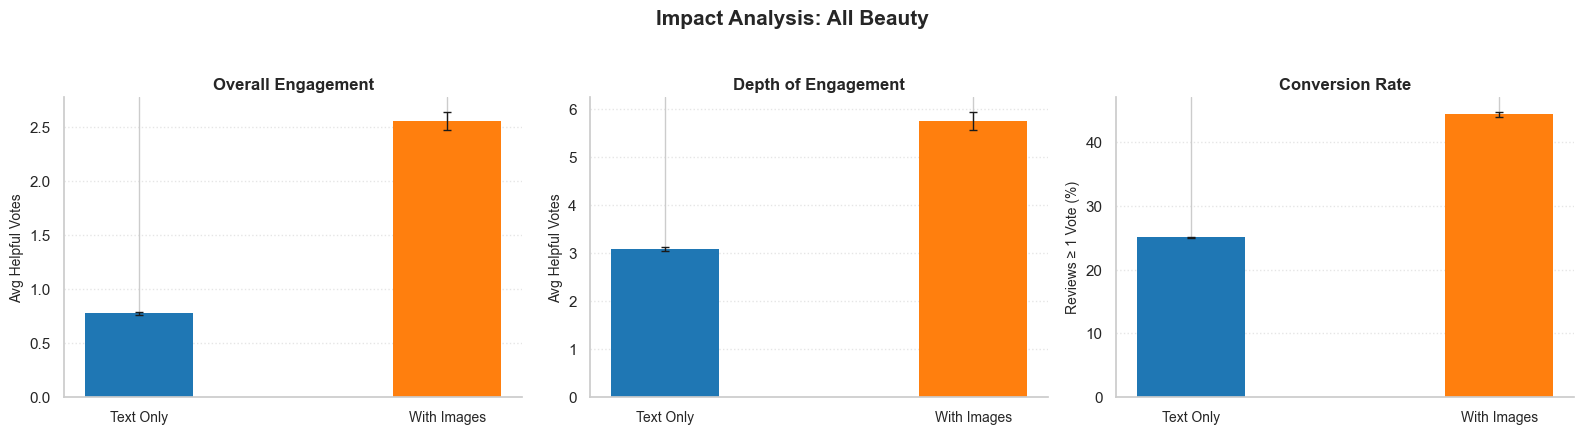

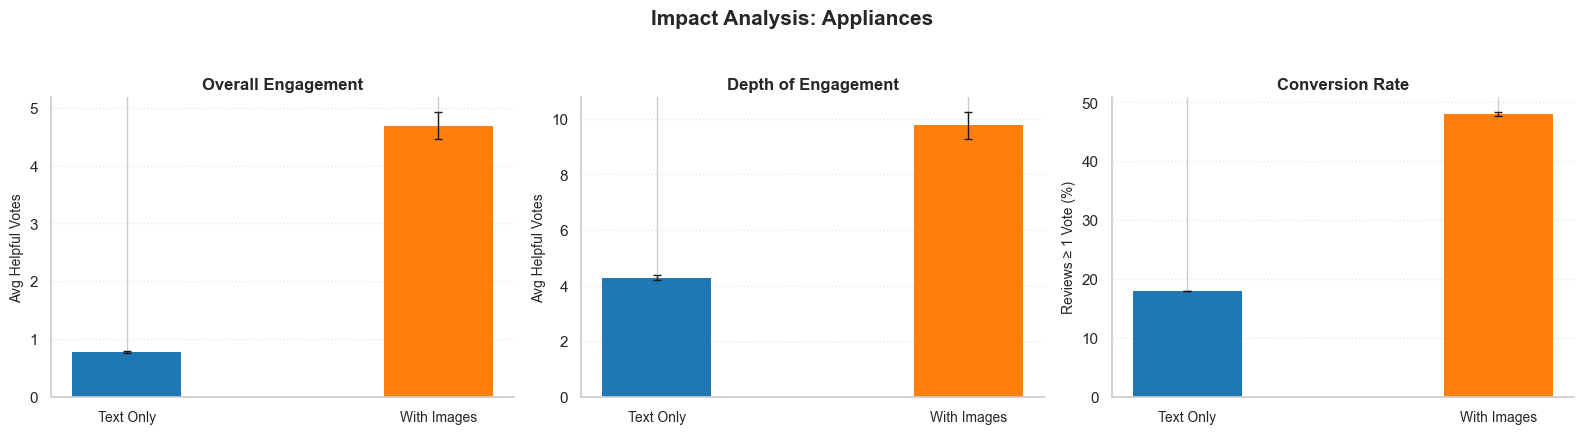

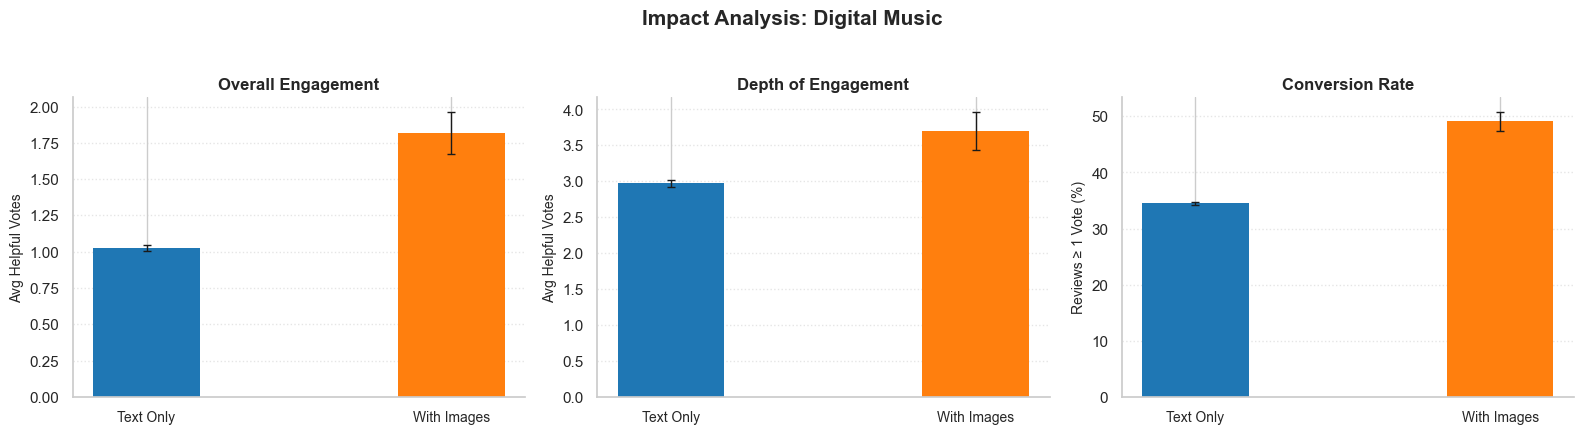

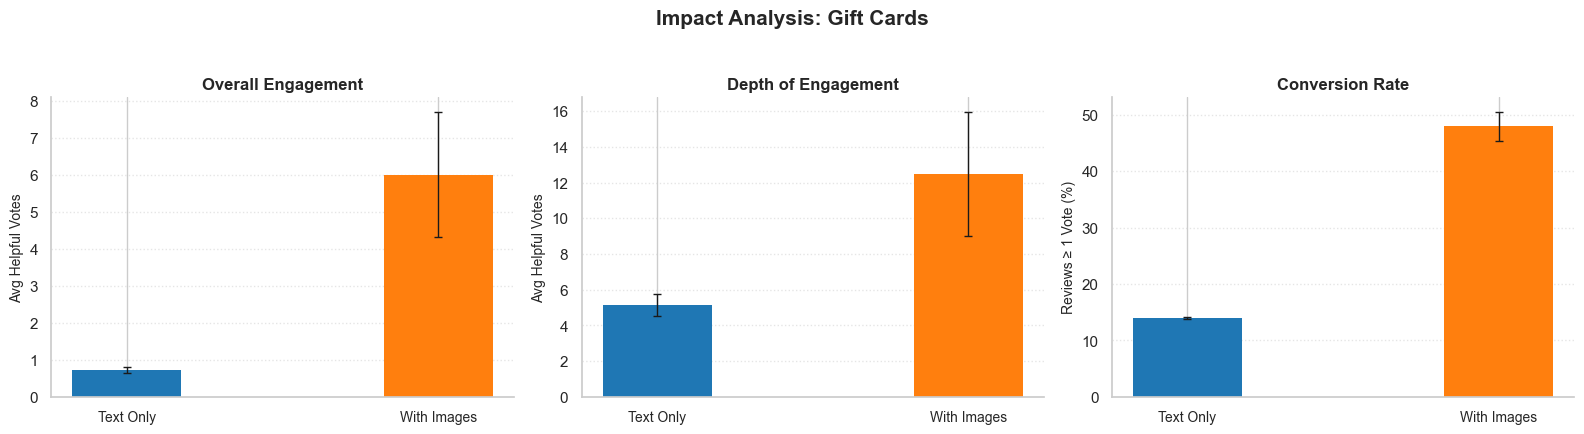

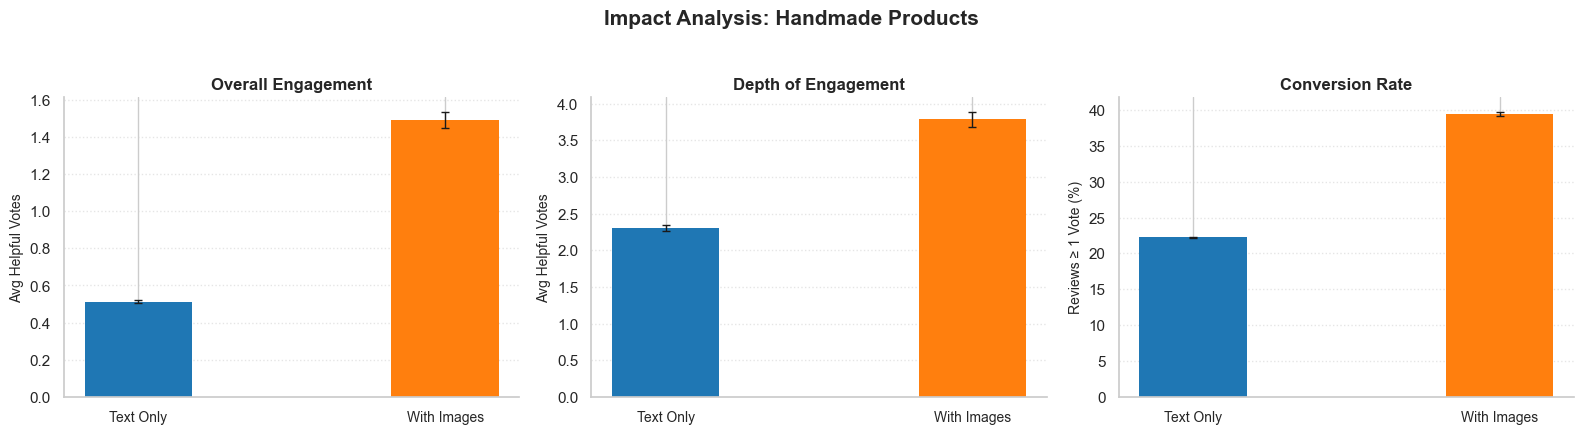

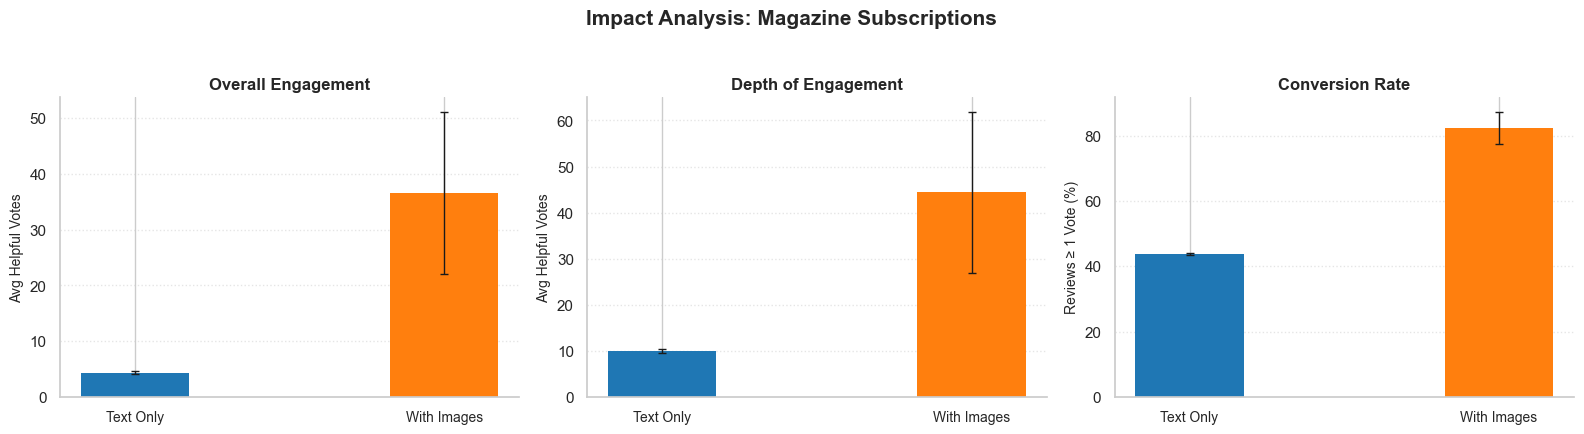

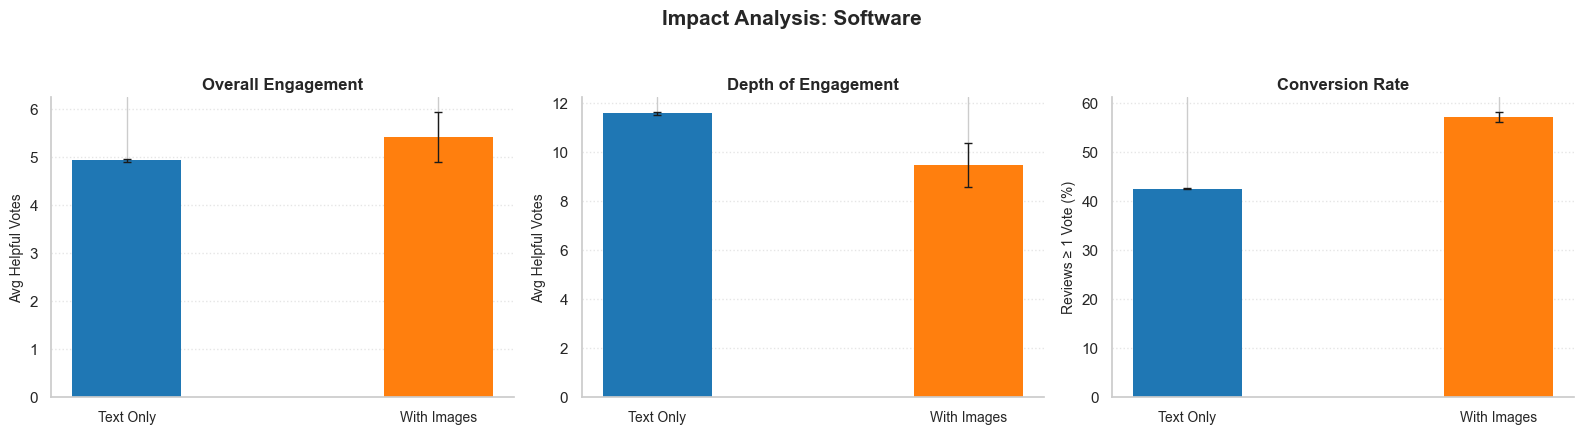

In [3]:
plot_df = pd.read_csv(os.path.join(CSV_PATH, "plot_ready_img_help.csv"))

sns.set_theme(style="whitegrid")

blue = "#1f77b4"
orange = "#ff7f0e"
colors = [blue, orange]
labels = ["Text Only", "With Images"]

for cat in plot_df["Category"].unique():
    df = plot_df[plot_df["Category"] == cat].sort_values("has_images")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    x = np.arange(2)
    width = 0.35

    # -------- Overall Engagement --------
    axes[0].bar(
        x,
        df["mean_helpful"],
        width=width,
        color=colors,
        edgecolor="none",
        yerr=df["ci95_helpful"],
        capsize=3,
        error_kw={"elinewidth": 1},
    )
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=10)
    axes[0].set_title(
        f"Overall Engagement",
        fontsize=12,
        weight="semibold",
    )
    axes[0].set_ylabel("Avg Helpful Votes", fontsize=10)

    # -------- Depth of Engagement (Votes > 0) --------
    axes[1].bar(
        x,
        df["cond_mean"],
        width=width,
        color=colors,
        edgecolor="none",
        yerr=df["cond_ci95"],
        capsize=3,
        error_kw={"elinewidth": 1},
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, fontsize=10)
    axes[1].set_title("Depth of Engagement", fontsize=12, weight="semibold")
    axes[1].set_ylabel("Avg Helpful Votes", fontsize=10)

    # -------- Conversion Rate --------
    axes[2].bar(
        x,
        df["conv_rate"],
        width=width,
        color=colors,
        edgecolor="none",
        yerr=df["conv_ci95"],
        capsize=3,
        error_kw={"elinewidth": 1},
    )
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, fontsize=10)
    axes[2].set_title("Conversion Rate", fontsize=12, weight="semibold")
    axes[2].set_ylabel("Reviews ≥ 1 Vote (%)", fontsize=10)

    for ax in axes:
        ax.grid(axis="y", linestyle=":", alpha=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(
        f"Impact Analysis: {cat.replace('_', ' ')}",
        fontsize=15,
        weight="bold",
        y=1.03,
    )

    plt.tight_layout()
    # Save each plot automatically
    plt.savefig(os.path.join(PLOTS_PATH, f"{cat}_img_help.png"), dpi=600)
    plt.show()
    plt.close()

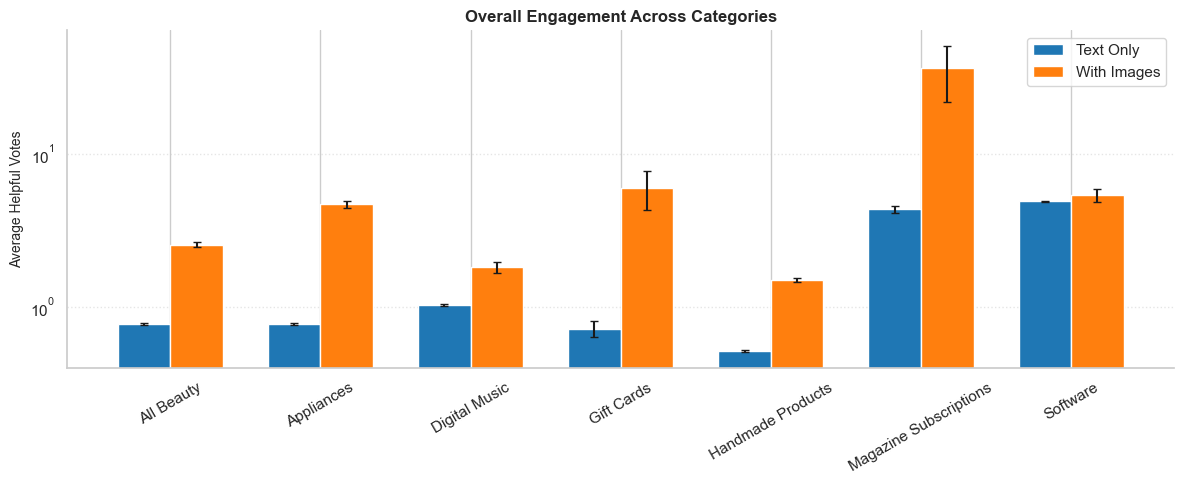

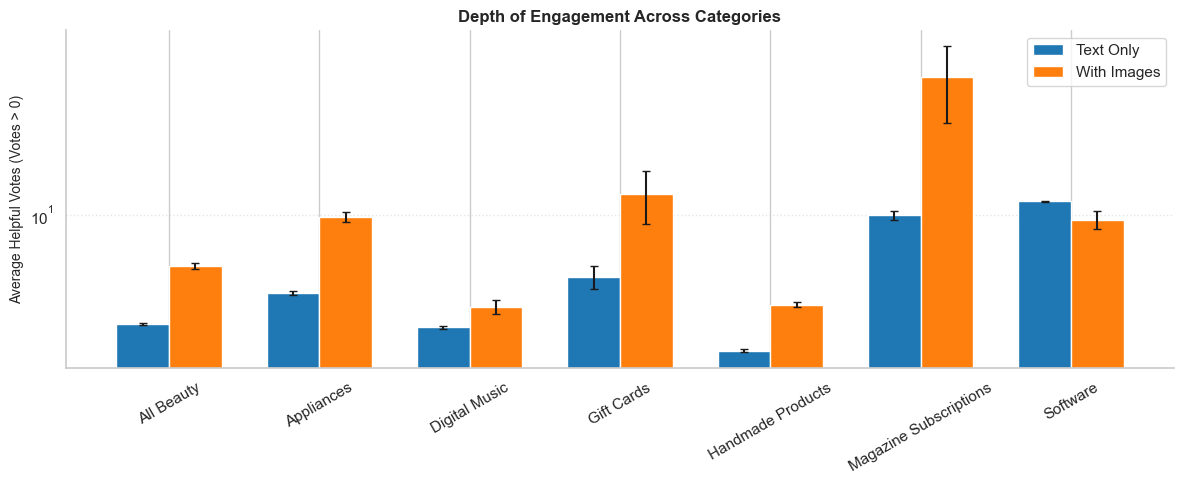

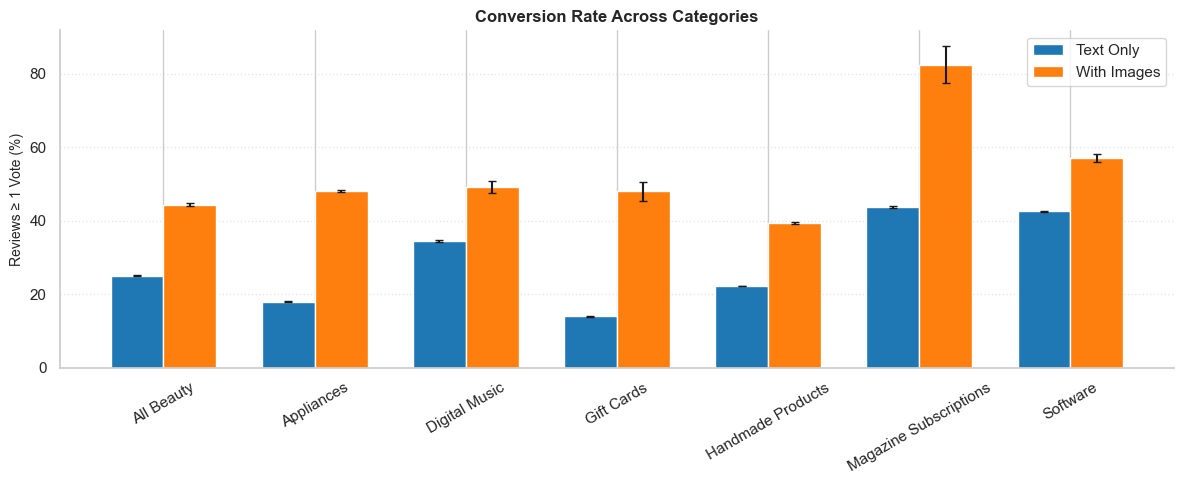

In [4]:
plot_df = pd.read_csv(os.path.join(CSV_PATH, "plot_ready_img_help.csv"))

sns.set_theme(style="whitegrid")

categories = plot_df["Category"].unique()
n = len(categories)
x = np.arange(n)
width = 0.35


def build_plot(
    metric, error_metric, ylabel, title, filename, log_scale=False, show_corr=False
):
    fig, ax = plt.subplots(figsize=(12, 5))

    text_vals, img_vals = [], []
    text_err, img_err = [], []

    for cat in categories:
        df_cat = plot_df[plot_df["Category"] == cat].sort_values("has_images")
        text_vals.append(df_cat[df_cat["has_images"] == False][metric].values[0])
        img_vals.append(df_cat[df_cat["has_images"] == True][metric].values[0])
        text_err.append(df_cat[df_cat["has_images"] == False][error_metric].values[0])
        img_err.append(df_cat[df_cat["has_images"] == True][error_metric].values[0])

    ax.bar(
        x - width / 2,
        text_vals,
        width,
        yerr=text_err,
        label="Text Only",
        color="#1f77b4",
        capsize=3,
    )

    ax.bar(
        x + width / 2,
        img_vals,
        width,
        yerr=img_err,
        label="With Images",
        color="#ff7f0e",
        capsize=3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", " ") for c in categories], rotation=30)
    ax.set_ylabel(ylabel, fontsize=10)

    if show_corr:
        # show correlation and p-value in the title of overall plot
        corr = plot_df[plot_df["Category"] == categories[0]]["Correlation"].iloc[0]
        p_val = plot_df[plot_df["Category"] == categories[0]]["P_Value"].iloc[0]
        ax.set_title(
            f"{title}\nPoint-biserial Corr: {corr:.2f}, p={p_val}",
            fontsize=12,
            weight="semibold",
        )
    else:
        ax.set_title(title, fontsize=12, weight="semibold")

    ax.legend()
    if log_scale:
        ax.set_yscale("log")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_PATH, f"{filename}.png"), dpi=600)
    plt.show()


# -------- Plot 1: Overall Engagement (with correlation in title) --------
build_plot(
    metric="mean_helpful",
    error_metric="ci95_helpful",
    ylabel="Average Helpful Votes",
    title="Overall Engagement Across Categories",
    log_scale=True,
    filename="overall_engagement",
    show_corr=False,
)

# -------- Plot 2: Conditional Engagement (Votes > 0) --------
build_plot(
    metric="cond_mean",
    error_metric="cond_ci95",
    ylabel="Average Helpful Votes (Votes > 0)",
    title="Depth of Engagement Across Categories",
    log_scale=True,
    filename="conditional_engagement",
    show_corr=False,
)

# -------- Plot 3: Conversion Rate --------
build_plot(
    metric="conv_rate",
    error_metric="conv_ci95",
    ylabel="Reviews ≥ 1 Vote (%)",
    title="Conversion Rate Across Categories",
    log_scale=False,
    filename="conversion_rate",
    show_corr=False,
)

#### Temporal Analysis

Completed filter + merge of metadata.


g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


...

g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


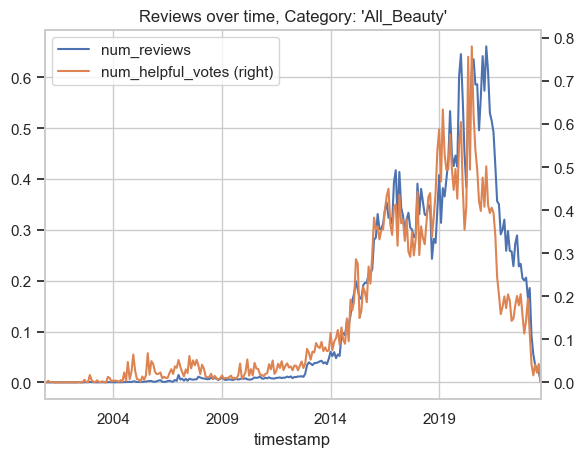

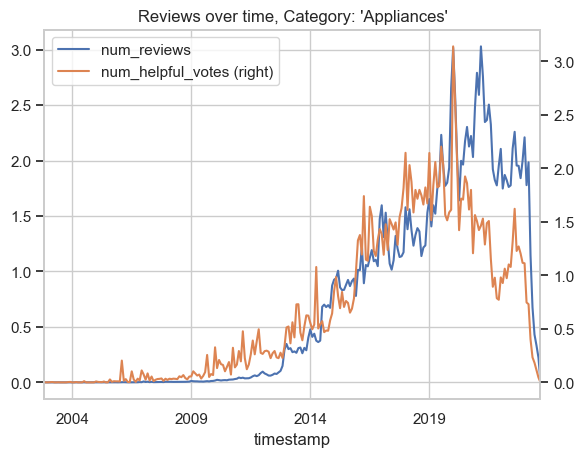

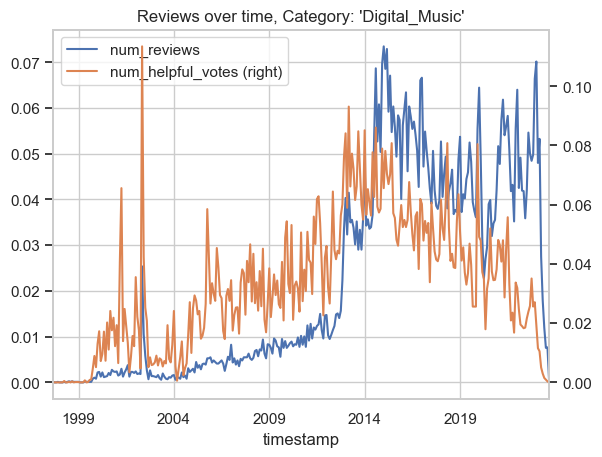

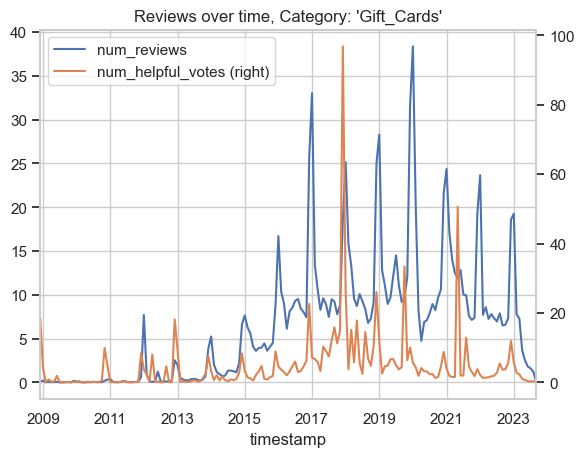

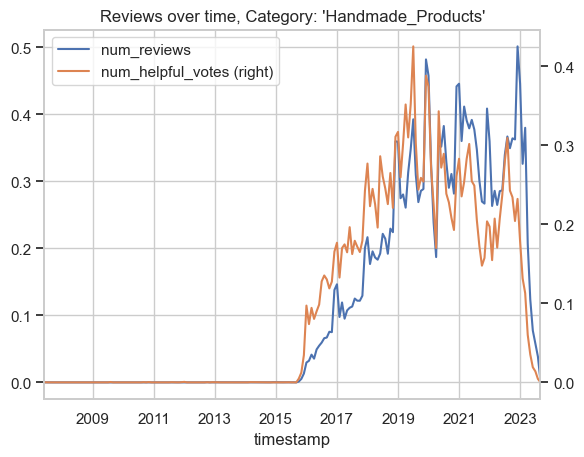

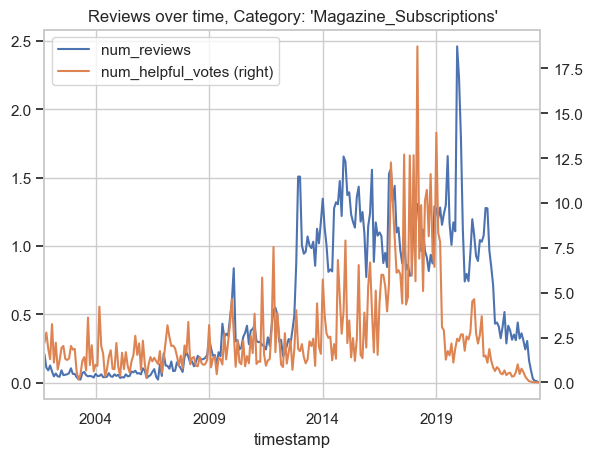

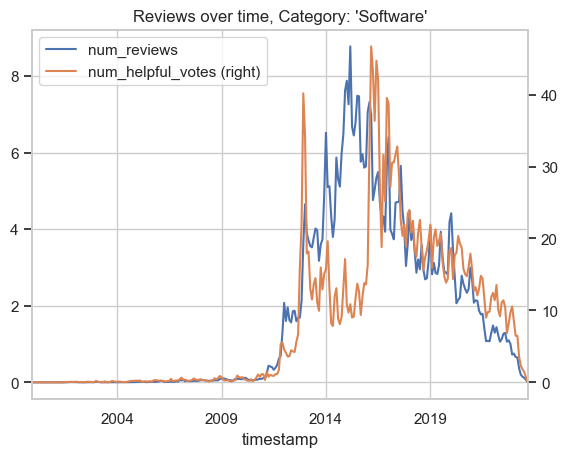

In [5]:
plot_data = dict()
for category in categories:
    time, num_reviews, helpful_votes = plot_reviews_over_time(category)
    plot_data[category] = [time, num_reviews, helpful_votes]

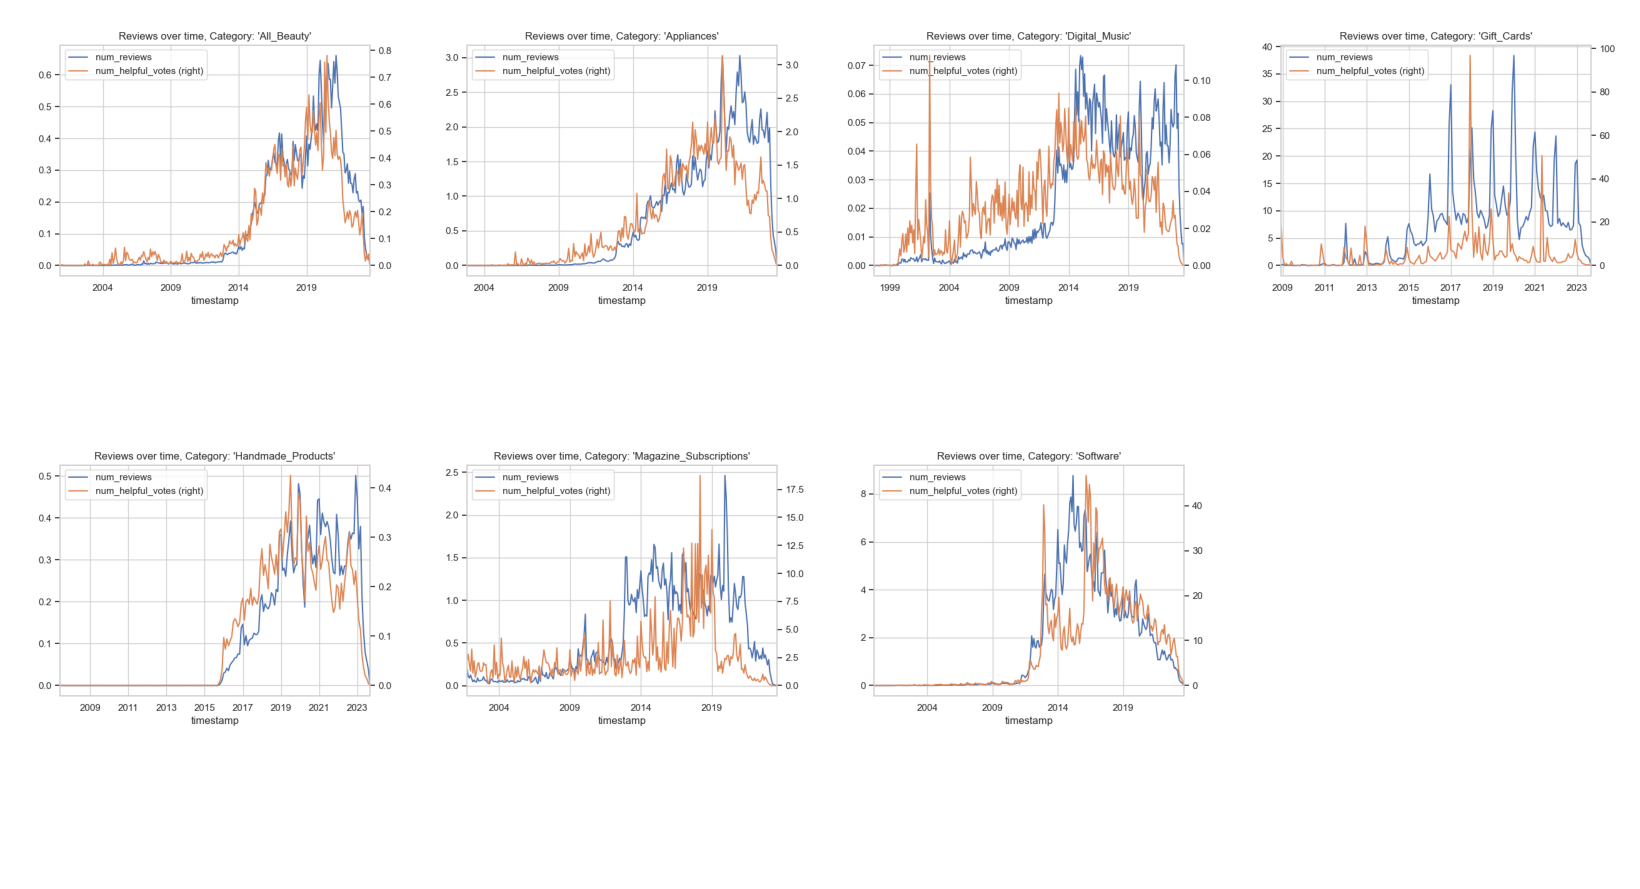

In [10]:
contents = os.listdir("plots/")

# 2. Filter for files that start with "temporal_"
temporal_files = [f for f in contents if f.startswith("temporal_")]
image_files = [os.path.join("plots/", f) for f in temporal_files]

num_images = min(len(image_files), 7)

fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for i in range(len(axes)):
    if i < num_images:
        img = mpimg.imread(image_files[i])
        axes[i].imshow(img)
        axes[i].axis("off")
    else:
        # Hide extra subplots if there are fewer than 6 images
        axes[i].axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig("plots/temporal_categories_reviews.png")
plt.show()

### Observations:
- It seems like a spike in reviews is almost always preceded by a spike in helpful votes
- Most of the categories seem to have a similar trend shape, with slow growth in the beginning followed by a sharp uptick in "popularity"

### Next Step:
- Perhaps, we can see if a lagged helpful votes variable actually is predictive of number of reviews or not

Generating correlation plot...
Correlation peaks at lag = 7
Computing OLS...
                            OLS Regression Results                            
Dep. Variable:                reviews   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1440.
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          4.60e-143
Time:                        13:34:07   Log-Likelihood:                 405.24
No. Observations:                 268   AIC:                            -804.5
Df Residuals:                     265   BIC:                            -793.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

ValueError: maxlag must be a positive integer

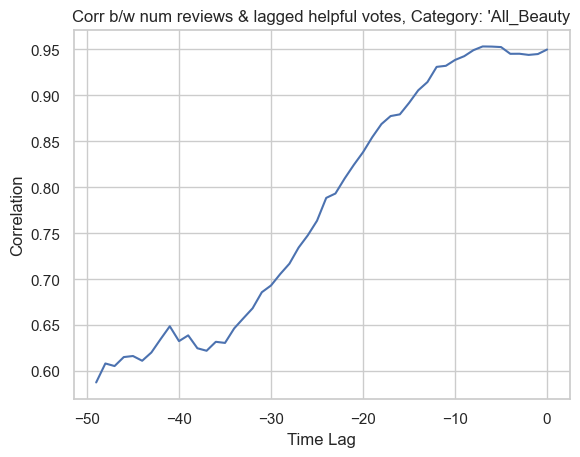

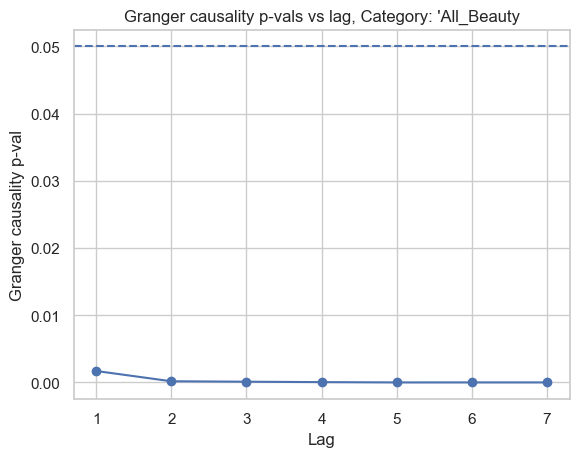

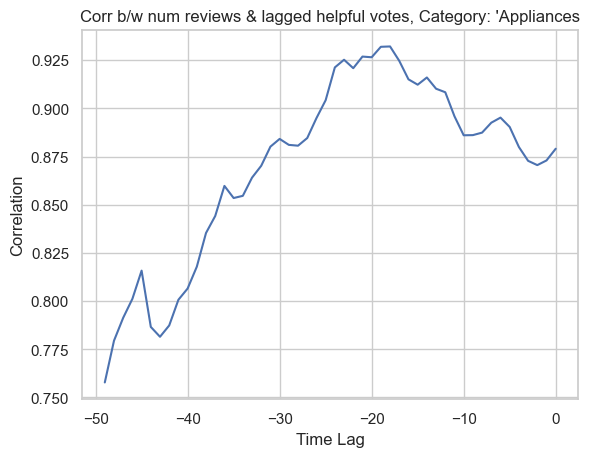

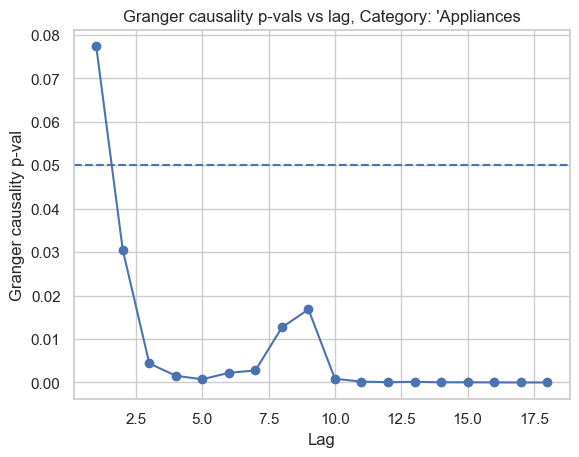

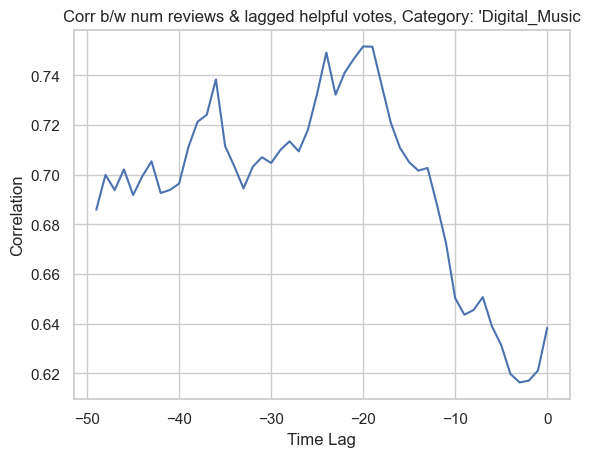

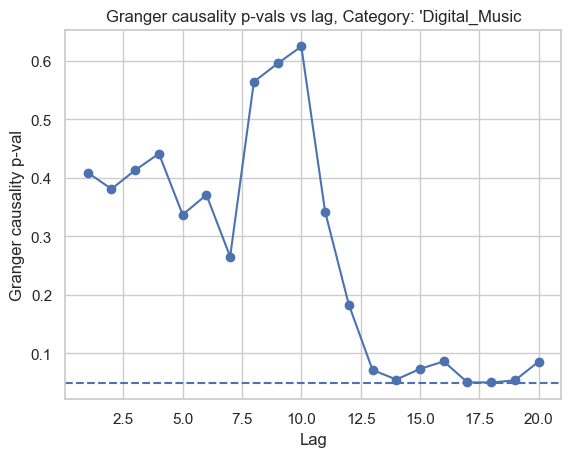

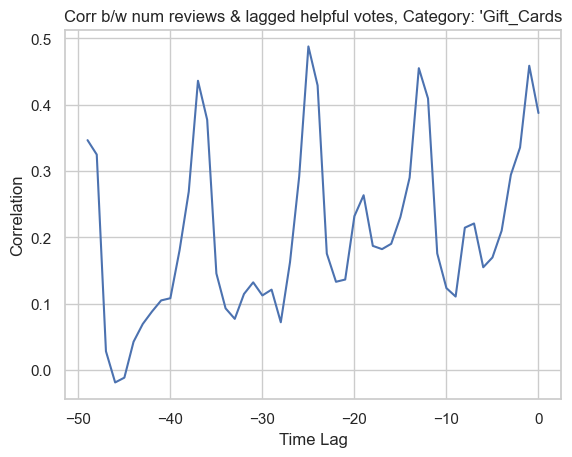

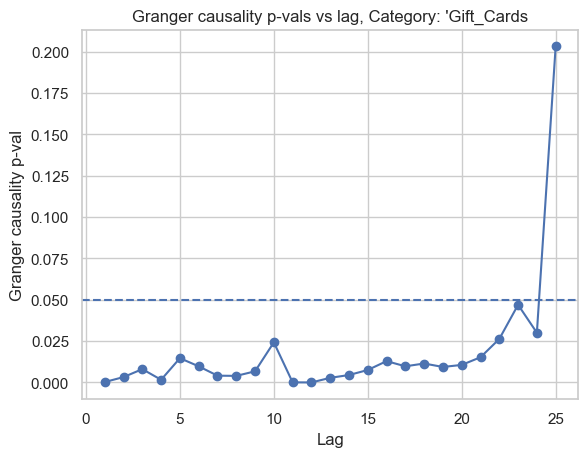

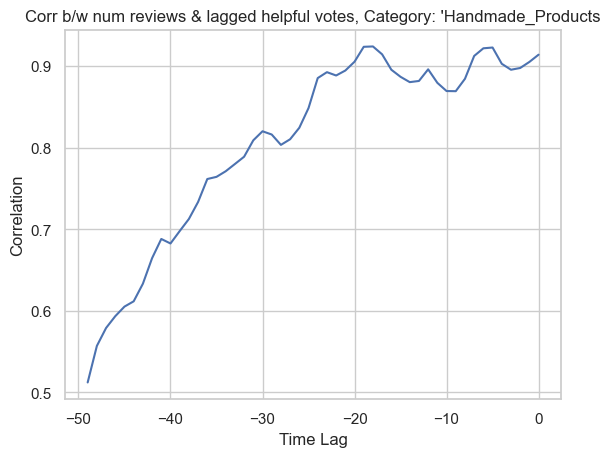

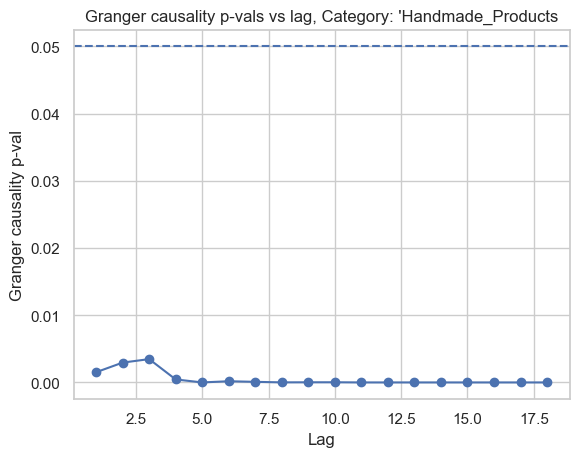

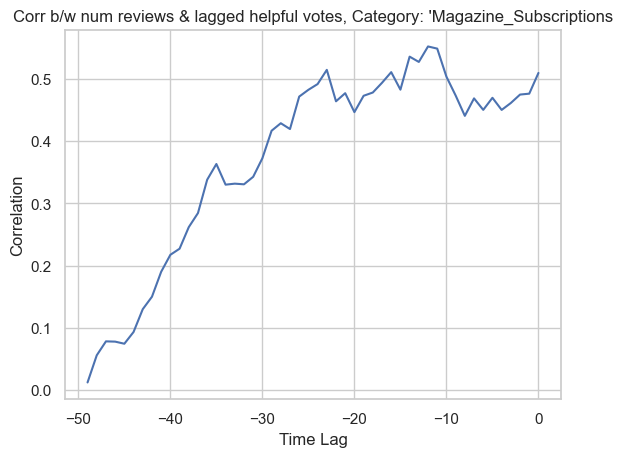

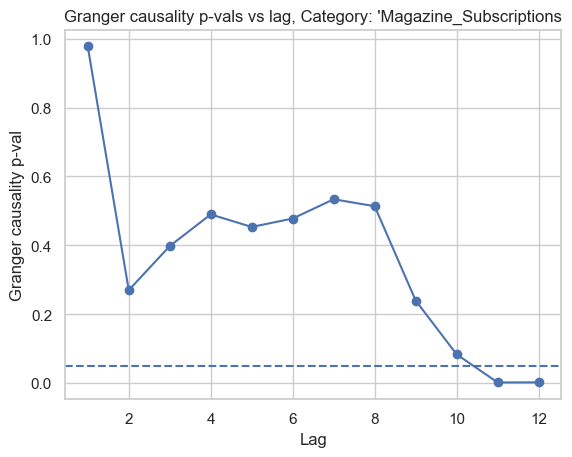

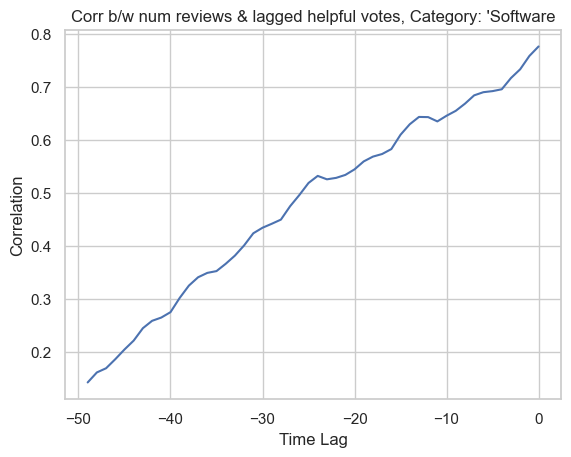

In [7]:
for category in categories:
    time, num_reviews, helpful_votes = plot_data[category]
    run_tests(time, num_reviews, helpful_votes, category=category)

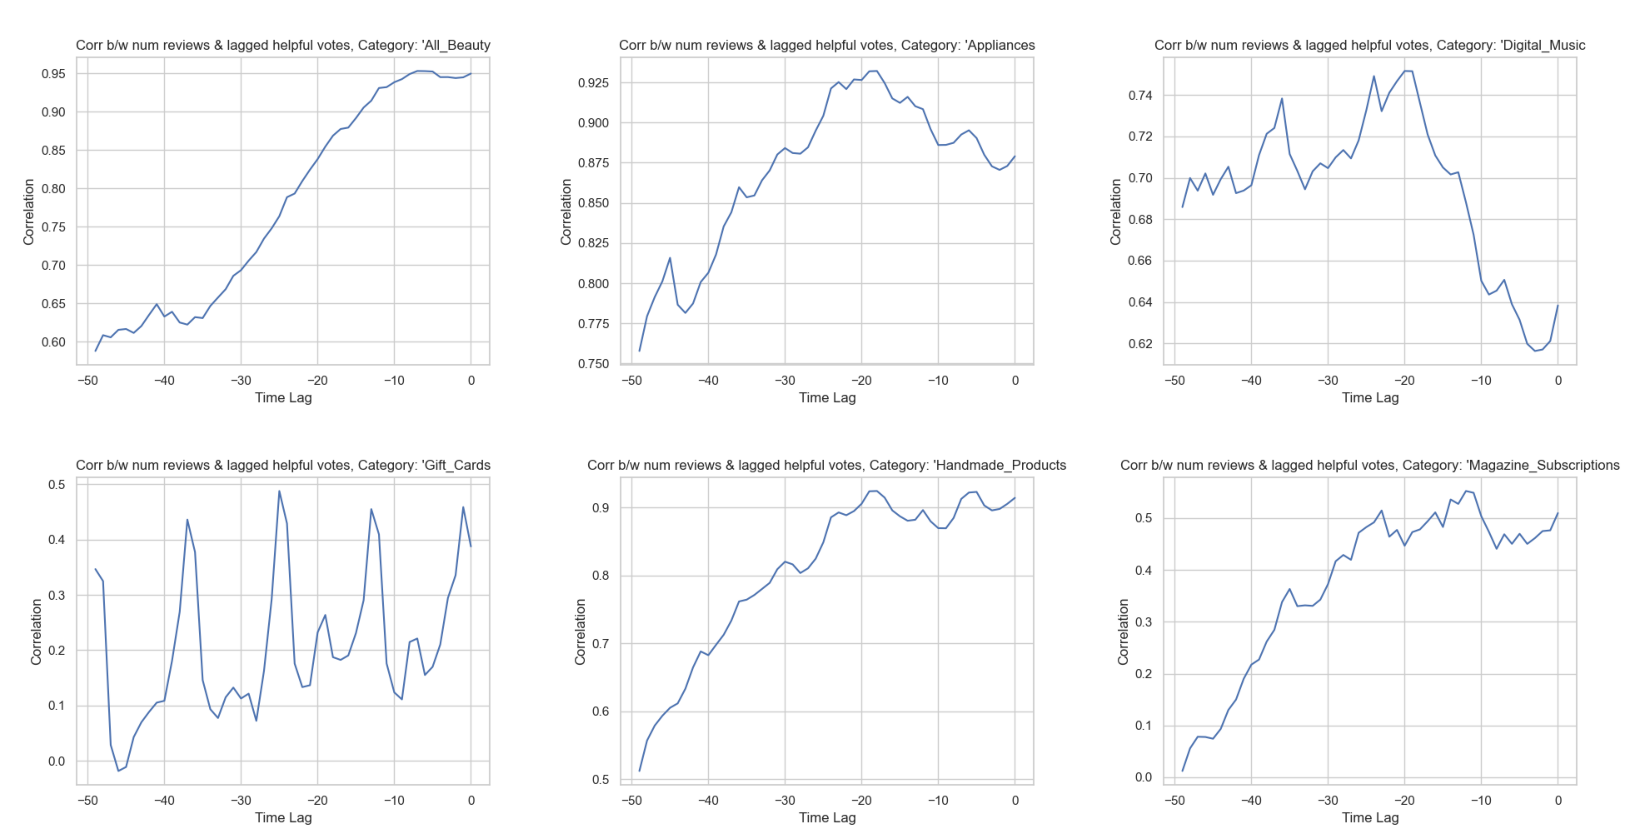

In [11]:
# Uncomment cell to generate a single figure with all the correlation plots

contents = os.listdir("plots/")
contents = list(filter(lambda x: x[:4] == "corr", contents))
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig("plots/categories_correlation.png")
plt.show()

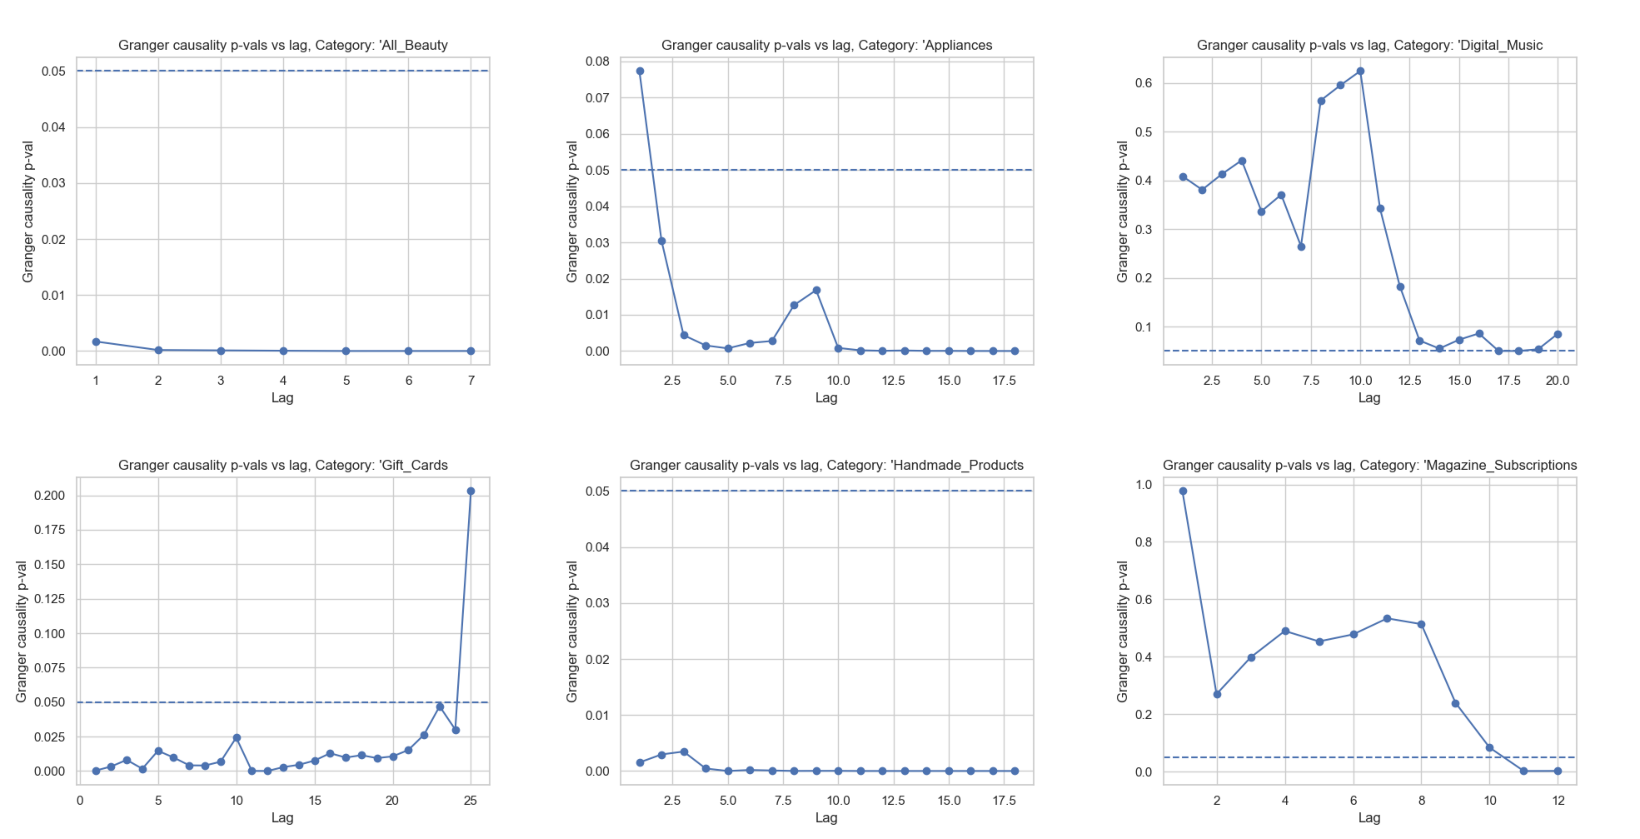

In [12]:
# Uncomment cell to generate a single figure with all the granger plots

contents = os.listdir("plots/")
contents = list(filter(lambda x: x[:7] == "granger", contents))
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig("plots/categories_granger.png")
plt.show()

### Observations:
- Correlation seems to increase as we use data from months that are more recent, but the increase is not linear
- For some categories, the highest correlated month is actually a few months back (not the most recent month)
- In the OLS analysis, we see that helpful votes for the highest correlated month is positively impacting num reviews with a p-value well below 0.01
- The Durbin-Watson metric is between 0.7 and 1.0 for all the OLS tests, which indicates moderate amounts of autocorrelation
- The Granger Causality test tells us that adding more months does not necessarily give us high-confidence relationships. A general trend though is a decrease in p-value to below the threshold of alpha = 0.05 as we add more months.

#### Test: Helpfulness based on Verified Purchase

<Figure size 1200x600 with 0 Axes>

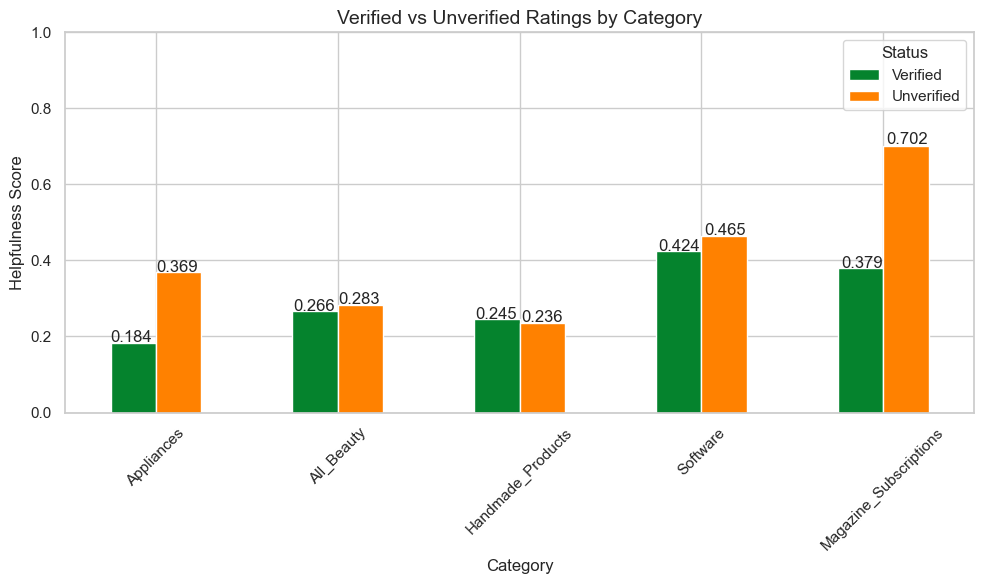

In [13]:
df = pd.read_csv("./csv/helpfulness_summary.csv")

result_dict = df.set_index('Category')[['Verified', 'Unverified']].to_dict(orient='index')
plt.figure(figsize=(12, 6))
ax = df.plot(x='Category', y=['Verified', 'Unverified'], kind='bar', figsize=(10, 6),color = ['#05832d', "#ff8100"])

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
ax.set_ylim(0, 1)
plt.title('Verified vs Unverified Ratings by Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()

# Save and Show
plt.savefig('verified_vs_unverified.png')
plt.show()

#### Test: Helpfulness based on Review Rating

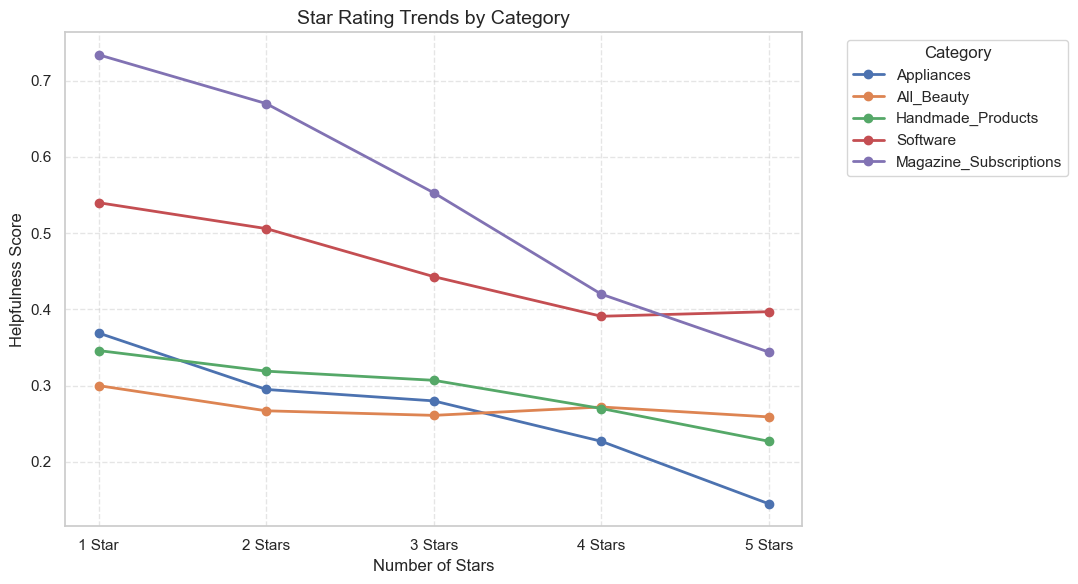

In [14]:
star_cols = ['One_Star', 'Two_Star', 'Three_Star', 'Four_Star', 'Five_Star']
star_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(11, 6))

for index, row in df.iterrows():
    plt.plot(star_labels, row[star_cols], marker='o', label=row['Category'], linewidth=2)
ax.set_ylim(0, 1)

plt.title('Star Rating Trends by Category', fontsize=14)
plt.xlabel('Number of Stars', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('regular_line_stars.png')
plt.show()

#### Test: Helpfulness Based on length of review

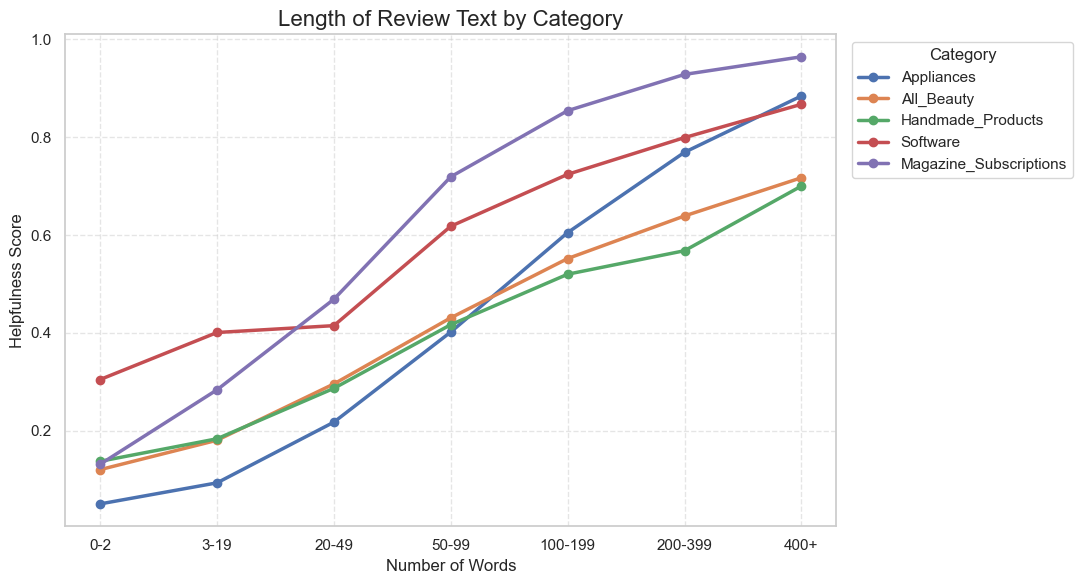

In [15]:
star_cols = ['0to2', '3to19', '20to49', '50to99', '100to199', '200to399', '400plus']
star_labels = ['0-2', '3-19', '20-49', '50-99', '100-199', '200-399', '400+']

plt.figure(figsize=(11, 6))

for index, row in df.iterrows():
    plt.plot(star_labels, row[star_cols], marker='o', label=row['Category'], linewidth=2.5)

plt.title('Length of Review Text by Category', fontsize=16)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)


plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('wide_line_chart.png')
plt.show()